In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv("../dataset/cars_dataset.csv")
data

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi
...,...,...,...,...,...,...,...,...,...,...
72430,I30,2016,8680,Manual,25906,Diesel,0.0,78.4,1.6,Hyundai
72431,I40,2015,7830,Manual,59508,Diesel,30.0,65.7,1.7,Hyundai
72432,I10,2017,6830,Manual,13810,Petrol,20.0,60.1,1.0,Hyundai
72433,Tucson,2018,13994,Manual,23313,Petrol,145.0,44.8,1.6,Hyundai


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         72435 non-null  str    
 1   year          72435 non-null  int64  
 2   price         72435 non-null  int64  
 3   transmission  72435 non-null  str    
 4   mileage       72435 non-null  int64  
 5   fuelType      72435 non-null  str    
 6   tax           72435 non-null  float64
 7   mpg           72435 non-null  float64
 8   engineSize    72435 non-null  float64
 9   Make          72435 non-null  str    
dtypes: float64(3), int64(3), str(4)
memory usage: 5.5 MB


In [4]:
data.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

In [5]:
data["fuelType"].unique()

<StringArray>
['Petrol', 'Diesel', 'Hybrid', 'Other', 'Electric']
Length: 5, dtype: str

In [6]:
data["Make"].unique()

<StringArray>
['audi', 'BMW', 'Ford', 'vw', 'toyota', 'skoda', 'Hyundai']
Length: 7, dtype: str

In [7]:
data["transmission"].unique()

<StringArray>
['Manual', 'Automatic', 'Semi-Auto', 'Other']
Length: 4, dtype: str

In [8]:
data["model"].unique()

<StringArray>
[      ' A1',       ' A6',       ' A4',       ' A3',       ' Q3',       ' Q5',
       ' A5',       ' S4',       ' Q2',       ' A7',
 ...
    ' Ioniq',     ' Kona', ' Veloster',     ' I800',     ' IX20', ' Santa Fe',
   ' Accent', ' Terracan',     ' Getz',    ' Amica']
Length: 146, dtype: str

In [9]:
#since there are 146 diff models, we will drop model col for this Model
data = data.drop("model", axis=1)

In [10]:
data

,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,2017,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi
1,2016,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi
2,2016,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi
3,2017,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi
4,2019,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi
...,...,...,...,...,...,...,...,...,...
72430,2016,8680,Manual,25906,Diesel,0.0,78.4,1.6,Hyundai
72431,2015,7830,Manual,59508,Diesel,30.0,65.7,1.7,Hyundai
72432,2017,6830,Manual,13810,Petrol,20.0,60.1,1.0,Hyundai
72433,2018,13994,Manual,23313,Petrol,145.0,44.8,1.6,Hyundai


In [11]:
X = data.drop("price", axis=1)
y = data["price"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [13]:
# now we will encode all the strings so we can use them in linear regression
# we can use sklearn onehotencoder (prefered for ML) or pandas get_dummies

from sklearn.preprocessing import OneHotEncoder

categorical_cols = ["Make", "fuelType", "transmission"]
encoder = OneHotEncoder(sparse_output=False, dtype=int, drop="first")

In [14]:
encoder.fit(X_train[categorical_cols])

X_train_encoded = encoder.transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

In [15]:
numerical_cols = [
    "year",
    "mileage",
    "tax",
    "mpg",
    "engineSize"
]

In [16]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_test_num = scaler.transform(X_test[numerical_cols])

In [17]:
X_train_final = np.concat([X_train_num, X_train_encoded], axis=1)
X_test_final = np.concat([X_test_num, X_test_encoded], axis=1)

In [18]:
print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape:", X_test_final.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train_final shape: (57948, 18)
X_test_final shape: (14487, 18)
y_train shape: (57948,)
y_test shape: (14487,)


In [19]:
model = LinearRegression()
model.fit(X_train_final, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](18,)","[ 3144.31,-1988.74, -120.36,...,-2145.09,-1206.07, 319.98]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.81e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,18
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(18)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](18,)","[347.67,298.72,221.32,..., 13.43, 1.96, 1.73]"


In [20]:
y_pred_sk = model.predict(X_test_final)

In [21]:
print(y_pred_sk[:10])

[21661.86647218 16471.34679109 25624.11362649 19139.73639328
 10710.11771713  8701.32890028 20455.31978109 13673.07865923
 18552.48151018 10688.25545196]


In [22]:
from sklearn.metrics import mean_squared_error, r2_score

MSE_SK = mean_squared_error(y_test, y_pred_sk)
RMSE_SK = MSE_SK ** 0.5
R2_SK = r2_score(y_test, y_pred_sk)

print("MSE:", MSE_SK)
print("RMSE:", RMSE_SK)
print("R2:", R2_SK)


MSE: 19018842.708691757
RMSE: 4361.059814849111
R2: 0.7643477117933435


In [23]:
print(y_test[:10], y_pred_sk[:10])

9798     19299
31968    16479
41338    19999
70992    18495
26406    11995
31952    10495
51446    20490
42814    13350
37527    19999
28072    11299
Name: price, dtype: int64 [21661.86647218 16471.34679109 25624.11362649 19139.73639328
 10710.11771713  8701.32890028 20455.31978109 13673.07865923
 18552.48151018 10688.25545196]


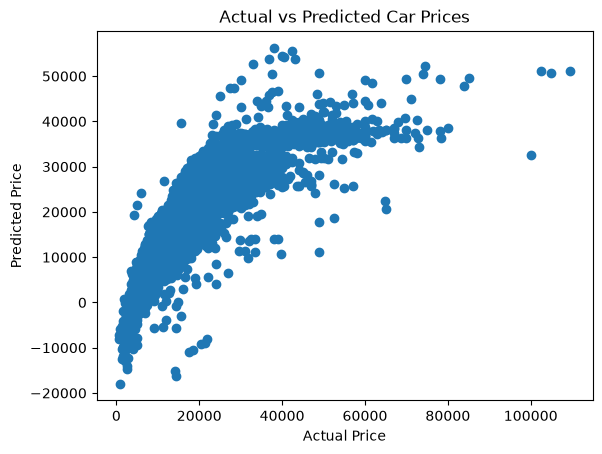

In [24]:
plt.scatter(y_test, y_pred_sk)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

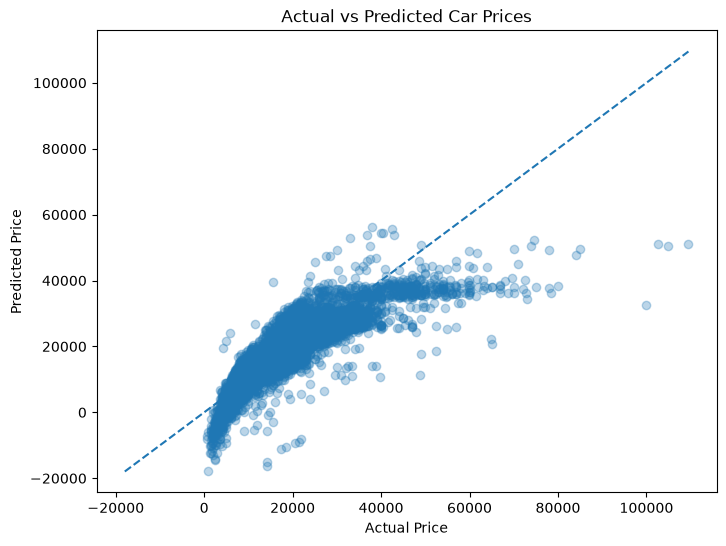

In [25]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_sk, alpha=0.3)

# Perfect prediction line
min_price = min(y_test.min(), y_pred_sk.min())
max_price = max(y_test.max(), y_pred_sk.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [26]:
from sklearn.metrics import mean_absolute_error

MAE = mean_absolute_error(y_test, y_pred_sk)
print("MAS: ", MAE)

MAS:  2827.2454064125623


In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_final)
X_test_poly = poly.transform(X_test_final)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

y_pred_poly = model_poly.predict(X_test_poly)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = mse_poly ** 0.5
r2_poly = r2_score(y_test, y_pred_poly)

print("MAE :", mae_poly)
print("RMSE:", rmse_poly)
print("R²  :", r2_poly)

MAE : 2123.1046232816702
RMSE: 3233.7631333571453
R²  : 0.870430141188866


In [29]:
from sklearn.metrics import mean_absolute_error

MAE = mean_absolute_error(y_test, y_pred_poly)
print("MAS: ", MAE)

MAS:  2123.1046232816702


In [30]:
import joblib

joblib.dump(encoder, "encoder.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(poly, "poly_features.pkl")
joblib.dump(model_poly, "model.pkl")

['model.pkl']

In [31]:
joblib.dump(model, "linear_model.pkl")

['linear_model.pkl']